In [50]:
import pandas as pd

In [51]:
df = pd.read_csv("/kaggle/input/research-multilabel-text/reviewsDataset.csv")
df.head()

,reviewContent,ground_truth_aspects
0,"আলহামদুলিল্লাহ, প্রোডাক্টটি অনেক ভালো! সাউন্ড ...","product, packaging"
1,"অসাধারণ একটা প্রডাক্ট হাতে পেলাম,সত্যিই অসাধার...","product, seller, packaging"
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller"
3,"যেমন ওর্ডার করেছি তেমন পেয়েছি,প্যাকেটিং ভালো ছ...","product, packaging, seller"
4,১০০% আসল প্রোডাক্ট। সিলেটের মধ্যে ৮ দিনের মধ্য...,"product, delivery, seller"


In [52]:
df.reviewContent[2]

'আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে নিতে পারেন যে রকম কথা ছিল সেই রকম দিসে ধ্যনবাদ দারাজ এবং সেলার '

In [53]:
import re
def replace_strings(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\u00C0-\u017F"          #latin
                           u"\u2000-\u206F"          #generalPunctuations
                               
                           "]+", flags=re.UNICODE)
    english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
    #latin_pattern=re.compile('[A-Za-z\u00C0-\u00D6\u00D8-\u00f6\u00f8-\u00ff\s]*',)
    
    text=emoji_pattern.sub(r'', text)
    text=english_pattern.sub(r'', text)

    return text

def remove_punctuations(my_str):
    # define punctuation
    punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰🤣⚽️✌�￰৷￰'''
    
    no_punct = ""
    for char in my_str:
        if char not in punctuations:
            no_punct = no_punct + char

    # display the unpunctuated string
    return no_punct

def preprocessing(text):
    out=remove_punctuations(replace_strings(text))
    return out

In [54]:
df['reviewContent'] = df.reviewContent.apply(lambda x: preprocessing(str(x)))

In [55]:
df.head()

,reviewContent,ground_truth_aspects
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,"product, packaging"
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,"product, seller, packaging"
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller"
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,"product, packaging, seller"
4,আসল প্রোডাক্ট সিলেটের মধ্যে দিনের মধ্যে ডেলি...,"product, delivery, seller"


In [56]:
# data1 =pd.read_excel('/kaggle/input/research-multilabel-text/stopwords_bangla-1.xlsx')
# stop = data1['words'].tolist()
# def stopwordRemoval(text):    
#     x=str(text)
#     l=x.split()

#     stm=[elem for elem in l if elem not in stop]
    
#     out=' '.join(stm)
    
#     return str(out)

# df['reviewContent'] = df.reviewContent.apply(lambda x: stopwordRemoval(str(x)))

In [57]:
df.shape

(1648, 2)

In [58]:
df.head()

,reviewContent,ground_truth_aspects
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,"product, packaging"
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,"product, seller, packaging"
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller"
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,"product, packaging, seller"
4,আসল প্রোডাক্ট সিলেটের মধ্যে দিনের মধ্যে ডেলি...,"product, delivery, seller"


In [59]:
df = df.dropna()

In [60]:
df.shape

(1581, 2)

In [61]:
# Create a set to hold unique aspects
unique_aspects = set()

# Split the aspects and update the unique_aspects set
df['ground_truth_aspects'].str.split(', ').apply(unique_aspects.update)

# Strip spaces from unique aspects and remove any empty strings
unique_aspects = {aspect.strip() for aspect in unique_aspects if aspect.strip()}

# Create a new column for each unique aspect and initialize with 0
for aspect in unique_aspects:
    df[aspect] = 0

# Populate the columns based on the aspects present in each row
for index, row in df.iterrows():
    aspects = [aspect.strip() for aspect in row['ground_truth_aspects'].split(', ')]
    for aspect in aspects:
        if aspect:  # only update if aspect is not an empty string
            df.at[index, aspect] = 1

In [62]:
df.head()

,reviewContent,ground_truth_aspects,"seller,shelf",packaging,price,service,delivery,rider,"product,price",product,seller,shelf,packaging product
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,"product, packaging",0,1,0,0,0,0,0,1,0,0,0
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,"product, seller, packaging",0,1,0,0,0,0,0,1,1,0,0
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,"product, seller",0,0,0,0,0,0,0,1,1,0,0
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,"product, packaging, seller",0,1,0,0,0,0,0,1,1,0,0
4,আসল প্রোডাক্ট সিলেটের মধ্যে দিনের মধ্যে ডেলি...,"product, delivery, seller",0,0,0,0,1,0,0,1,1,0,0


In [63]:
df.columns

Index(['reviewContent', 'ground_truth_aspects', 'seller,shelf', 'packaging',
       'price', 'service', 'delivery', 'rider', 'product,price', 'product',
       'seller', 'shelf', 'packaging  product'],
      dtype='object')

In [64]:
drop_columns = ["ground_truth_aspects", "packaging  product", "seller,shelf", "product,price"]
df = df.drop(columns=drop_columns, axis = 1)

In [65]:
df.head()

,reviewContent,packaging,price,service,delivery,rider,product,seller,shelf
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,1,0,0,0,0,1,0,0
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,1,0,0,0,0,1,1,0
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,0,0,0,0,0,1,1,0
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,1,0,0,0,0,1,1,0
4,আসল প্রোডাক্ট সিলেটের মধ্যে দিনের মধ্যে ডেলি...,0,0,0,1,0,1,1,0


In [66]:
df.reviewContent[2]

'আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে নিতে পারেন যে রকম কথা ছিল সেই রকম দিসে ধ্যনবাদ দারাজ এবং সেলার '

In [67]:
from sklearn.model_selection import train_test_split
# split into train and test
df_train, df_test = train_test_split(df, random_state=77, test_size=0.30, shuffle=True)
# split test into test and validation datasets
df_valid, df_test = train_test_split(df_test, random_state=88, test_size=0.33, shuffle=True)

In [68]:
print(f"Train: {df_train.shape}, Test: {df_test.shape}, Valid: {df_valid.shape}")

Train: (1106, 9), Test: (157, 9), Valid: (318, 9)


In [69]:
# Hyperparameters
MAX_LEN = 256
TRAIN_BATCH_SIZE = 32
VALID_BATCH_SIZE = 32
TEST_BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 1e-05
THRESHOLD = 0.5 # threshold for the sigmoid
     

In [70]:
from transformers import BertTokenizer, BertModel

import os
import pandas as pd
import numpy as np
import shutil
import sys
import tqdm.notebook as tq
from collections import defaultdict

import torch
import torch.nn as nn

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [71]:
tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')

vocab.txt:   0%|          | 0.00/2.24M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

In [72]:
# Test the tokenizer
test_text = "আলহামদুলিল্লাহ, প্রোডাক্টটি অনেক ভালো! সাউন্ড চেক করে দেখলাম অনেক ভালই! আপনার চোখ বন্ধ করে ভরসা করে নিতে পারেন! প্রোডাক্টটি যখন আমার হাতে এসেছিল তখন ইনটেক ছিল!"
# generate encodings
encodings = tokenizer.encode_plus(test_text, 
                                  add_special_tokens = True,
                                  max_length = 50,
                                  truncation = True,
                                  padding = "max_length", 
                                  return_attention_mask = True, 
                                  return_tensors = "pt")
# we get a dictionary with three keys (see: https://huggingface.co/transformers/glossary.html) 
encodings
     

{'input_ids': tensor([[  101,  2493, 16988, 11119, 11466, 40145,  1011,  2193, 70625, 22146,
          2294,  2115,  5477,  2094,  2395,   999, 41092,  2392,  3447,  4874,
          2039,  6456,  2115,  5477,  2062,   999,  2373, 10790, 39916, 32188,
          2039,  7236,  2039,  2261,  2207,   999,  2193, 70625, 22146,  2294,
          2241,  2211,  2317,  5432,  2213, 87401,  2072,   999,   102,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 0]])}

In [73]:
df_train['reviewContent']

1359    পণ্য ও গুণমান খুব ভালো মনে হয় আমার কাছে আপনি ...
672     আলহামদুলিল্লাহ্ সব দিকেই পারফেক্ট ছিলো সবাই নি...
736               নতুন উৎপাদিত প্রোডাক্ট থ্যাংকস টু সেলার
966     প্রোডাক্ট সম্পর্কে বলার কিছুই নাই কারণ আমার সব...
223     আলহামদুলিল্লাহ ভালো মতই পেয়েছি আমি সবসময় দারাজ...
                              ...                        
936     শেষমেশ কন্টেইনারসহ দেওয়া হয়েছে প্রথমে বলছিল ...
1358    কফি অসাধারণ ছিল কন্টেইনার এর লোভে নেওয়া তবে কন...
236      রিভিউ করেছেন লিমন আজাদ সানি \nপ্রোডাক্টটি অনে...
608                             খুব সুন্দর এবং সুস্বাদু 🥰
729                                    অরিজিনাল পণ্য গুলো
Name: reviewContent, Length: 1106, dtype: object

In [74]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len, target_list):
        self.tokenizer = tokenizer
        self.df = df
        self.title = list(df['reviewContent'])
        self.targets = self.df[target_list].values
        self.max_len = max_len

    def __len__(self):
        return len(self.title)

    def __getitem__(self, index):
        title = str(self.title[index])
        title = " ".join(title.split())
        inputs = self.tokenizer.encode_plus(
            title,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_token_type_ids=True,
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'token_type_ids': inputs["token_type_ids"].flatten(),
            'targets': torch.FloatTensor(self.targets[index]),
            'title': title
        }
     

In [75]:
target_list = list(df.columns)
target_list

['reviewContent',
 'packaging',
 'price',
 'service',
 'delivery',
 'rider',
 'product',
 'seller',
 'shelf']

In [76]:
target_list = target_list[1:]

In [77]:
target_list

['packaging',
 'price',
 'service',
 'delivery',
 'rider',
 'product',
 'seller',
 'shelf']

In [78]:
train_dataset = CustomDataset(df_train, tokenizer, MAX_LEN, target_list)
valid_dataset = CustomDataset(df_valid, tokenizer, MAX_LEN, target_list)
test_dataset = CustomDataset(df_test, tokenizer, MAX_LEN, target_list)

In [79]:
# testing the dataset
next(iter(train_dataset))

{'input_ids': tensor([  101, 20676,  9294,  2038,  5406,  6358,  5356,  4282,  5477,  2094,
          2395,  2139, 33668,  2211,  2152,  2536,  2166,  2045, 20676,  9294,
          2294,  3776,  2745,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [80]:
# Data loaders
train_data_loader = torch.utils.data.DataLoader(train_dataset, 
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_data_loader = torch.utils.data.DataLoader(valid_dataset, 
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_data_loader = torch.utils.data.DataLoader(test_dataset, 
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [81]:
class BERTClass(torch.nn.Module):
    def __init__(self):
        super(BERTClass, self).__init__()
        self.bert_model = BertModel.from_pretrained('sagorsarker/bangla-bert-base', return_dict=True)
        self.dropout = torch.nn.Dropout(0.3)
        self.linear = torch.nn.Linear(768, 8)

    def forward(self, input_ids, attn_mask, token_type_ids):
        output = self.bert_model(
            input_ids, 
            attention_mask=attn_mask, 
            token_type_ids=token_type_ids
        )
        output_dropout = self.dropout(output.pooler_output)
        output = self.linear(output_dropout)
        return output

model = BERTClass()

# # Freezing BERT layers: (tested, weaker convergence)
# for param in model.bert_model.parameters():
#     param.requires_grad = False

model.to(device)

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

BERTClass(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(102025, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [82]:
# BCEWithLogitsLoss combines a Sigmoid layer and the BCELoss in one single class. 
# This version is more numerically stable than using a plain Sigmoid followed 
# by a BCELoss as, by combining the operations into one layer, 
# we take advantage of the log-sum-exp trick for numerical stability.
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [83]:
from torch.optim import AdamW # Importing AdamW from torch.optim

# define the optimizer
optimizer = AdamW(model.parameters(), lr = 1e-5)

In [84]:
# Training of the model for one epoch
def train_model(training_loader, model, optimizer):

    losses = []
    correct_predictions = 0
    num_samples = 0
    # set model to training mode (activate droput, batch norm)
    model.train()
    # initialize the progress bar
    loop = tq.tqdm(enumerate(training_loader), total=len(training_loader), 
                      leave=True, colour='steelblue')
    for batch_idx, data in loop:
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        # forward
        outputs = model(ids, mask, token_type_ids) # (batch,predict)=(32,8)
        loss = loss_fn(outputs, targets)
        losses.append(loss.item())
        # training accuracy, apply sigmoid, round (apply thresh 0.5)
        outputs = torch.sigmoid(outputs).cpu().detach().numpy().round()
        targets = targets.cpu().detach().numpy()
        correct_predictions += np.sum(outputs==targets)
        num_samples += targets.size   # total number of elements in the 2D array

        # backward
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # grad descent step
        optimizer.step()

        # Update progress bar
        #loop.set_description(f"")
        #loop.set_postfix(batch_loss=loss)

    # returning: trained model, model accuracy, mean loss
    return model, float(correct_predictions)/num_samples, np.mean(losses)

In [85]:
def eval_model(validation_loader, model, optimizer):
    losses = []
    correct_predictions = 0
    num_samples = 0
    # set model to eval mode (turn off dropout, fix batch norm)
    model.eval()

    with torch.no_grad():
        for batch_idx, data in enumerate(validation_loader, 0):
            ids = data['input_ids'].to(device, dtype = torch.long)
            mask = data['attention_mask'].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data['targets'].to(device, dtype = torch.float)
            outputs = model(ids, mask, token_type_ids)

            loss = loss_fn(outputs, targets)
            losses.append(loss.item())

            # validation accuracy
            # add sigmoid, for the training sigmoid is in BCEWithLogitsLoss
            outputs = torch.sigmoid(outputs).cpu().detach().numpy().round()
            targets = targets.cpu().detach().numpy()
            correct_predictions += np.sum(outputs==targets)
            num_samples += targets.size   # total number of elements in the 2D array

    return float(correct_predictions)/num_samples, np.mean(losses)

**Model Training**

In [86]:
history = defaultdict(list)
best_accuracy = 0

for epoch in range(1, EPOCHS+1):
    print(f'Epoch {epoch}/{EPOCHS}')
    model, train_acc, train_loss = train_model(train_data_loader, model, optimizer)
    val_acc, val_loss = eval_model(val_data_loader, model, optimizer)

    print(f'train_loss={train_loss:.4f}, val_loss={val_loss:.4f} train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    # save the best model
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), "MLTC_model_state.bin")
        best_accuracy = val_acc
        
# https://github.com/dtolk/multilabel-BERT/blob/master/notebooks/multi_label_text_classification_BERT.ipynb

Epoch 1/100


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.4863, val_loss=0.4148 train_acc=0.7940, val_acc=0.8286
Epoch 2/100


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.3912, val_loss=0.3556 train_acc=0.8365, val_acc=0.8636
Epoch 3/100


...

train_loss=0.0050, val_loss=0.2323 train_acc=0.9997, val_acc=0.9375
Epoch 99/100


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.0049, val_loss=0.2313 train_acc=0.9999, val_acc=0.9395
Epoch 100/100


  0%|          | 0/35 [00:00<?, ?it/s]

train_loss=0.0049, val_loss=0.2315 train_acc=0.9995, val_acc=0.9391


In [87]:
import matplotlib.pyplot as plt

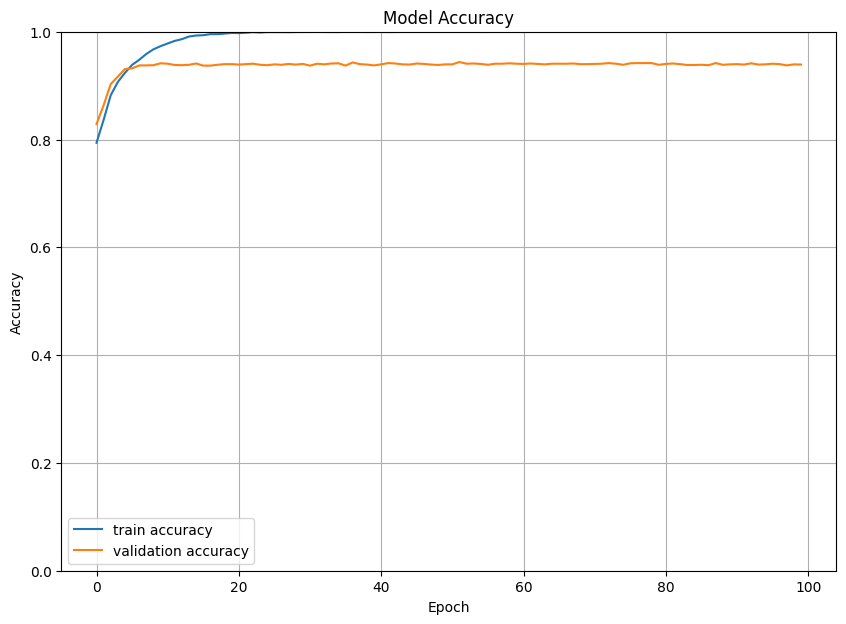

In [88]:
plt.rcParams["figure.figsize"] = (10,7)
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);
plt.grid()

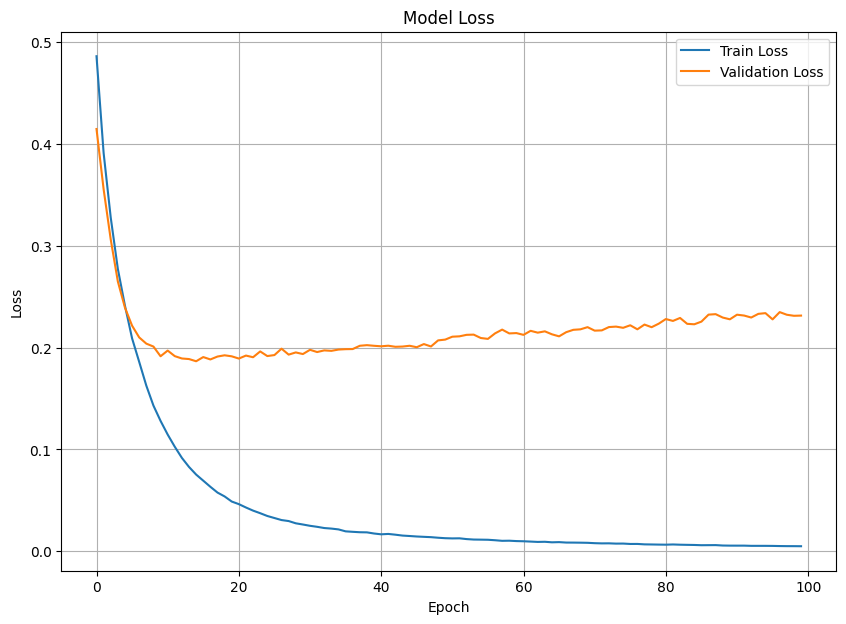

In [89]:
# Plot Loss
plt.rcParams["figure.figsize"] = (10,7)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

**Evaluation of the model**

In [90]:
# Loading pretrained model (best model)
model = BERTClass()
model.load_state_dict(torch.load("/kaggle/working/MLTC_model_state.bin"))
model = model.to(device)
     

/tmp/ipykernel_85/2735430275.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/working/MLTC_model_state.bin"))


In [91]:
# Evaluate the model using the test data
test_acc, test_loss = eval_model(test_data_loader, model, optimizer)

In [92]:

# The accuracy looks OK, similar to the validation accuracy
# The model generalizes well !
test_acc

0.9363057324840764

In [118]:
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Test Accuracy: 0.9363, Test Loss: 0.2377


In [93]:
from sklearn.metrics import confusion_matrix, classification_report

In [94]:
def get_predictions(model, data_loader):
    """
    Outputs:
      predictions - 
    """
    model = model.eval()
    
    titles = []
    predictions = []
    prediction_probs = []
    target_values = []

    with torch.no_grad():
        for data in data_loader:
            title = data["title"]
            ids = data["input_ids"].to(device, dtype = torch.long)
            mask = data["attention_mask"].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data["targets"].to(device, dtype = torch.float)

            outputs = model(ids, mask, token_type_ids)
            # add sigmoid, for the training sigmoid is in BCEWithLogitsLoss
            outputs = torch.sigmoid(outputs).detach().cpu()
            # thresholding at 0.5
            preds = outputs.round()
            targets = targets.detach().cpu()

            titles.extend(title)
            predictions.extend(preds)
            prediction_probs.extend(outputs)
            target_values.extend(targets)

    predictions = torch.stack(predictions)
    prediction_probs = torch.stack(prediction_probs)
    target_values = torch.stack(target_values)
    
    return titles, predictions, prediction_probs, target_values

In [95]:
titles, predictions, prediction_probs, target_values = get_predictions(model, test_data_loader)

In [96]:
# sanity check
predictions.numpy()

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.]], dtype=float32)

In [97]:
print(f"titles:{len(titles)} \npredictions:{predictions.shape} \nprediction_probs:{prediction_probs.shape} \ntarget_values:{target_values.shape}")

titles:157 
predictions:torch.Size([157, 8]) 
prediction_probs:torch.Size([157, 8]) 
target_values:torch.Size([157, 8])


In [98]:
# Generate Classification Metrics
#
# note that the total support is greater than the number of samples
# some samples have multiple lables

print(classification_report(target_values, predictions, target_names=target_list))

              precision    recall  f1-score   support

   packaging       0.88      0.91      0.90        47
       price       0.82      0.88      0.85        26
     service       0.80      0.25      0.38        16
    delivery       0.93      0.86      0.89        29
       rider       1.00      0.25      0.40         4
     product       0.85      0.89      0.87       104
      seller       0.79      0.85      0.82        27
       shelf       1.00      0.75      0.86        12

   micro avg       0.86      0.83      0.85       265
   macro avg       0.88      0.71      0.75       265
weighted avg       0.86      0.83      0.83       265
 samples avg       0.86      0.85      0.84       265



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


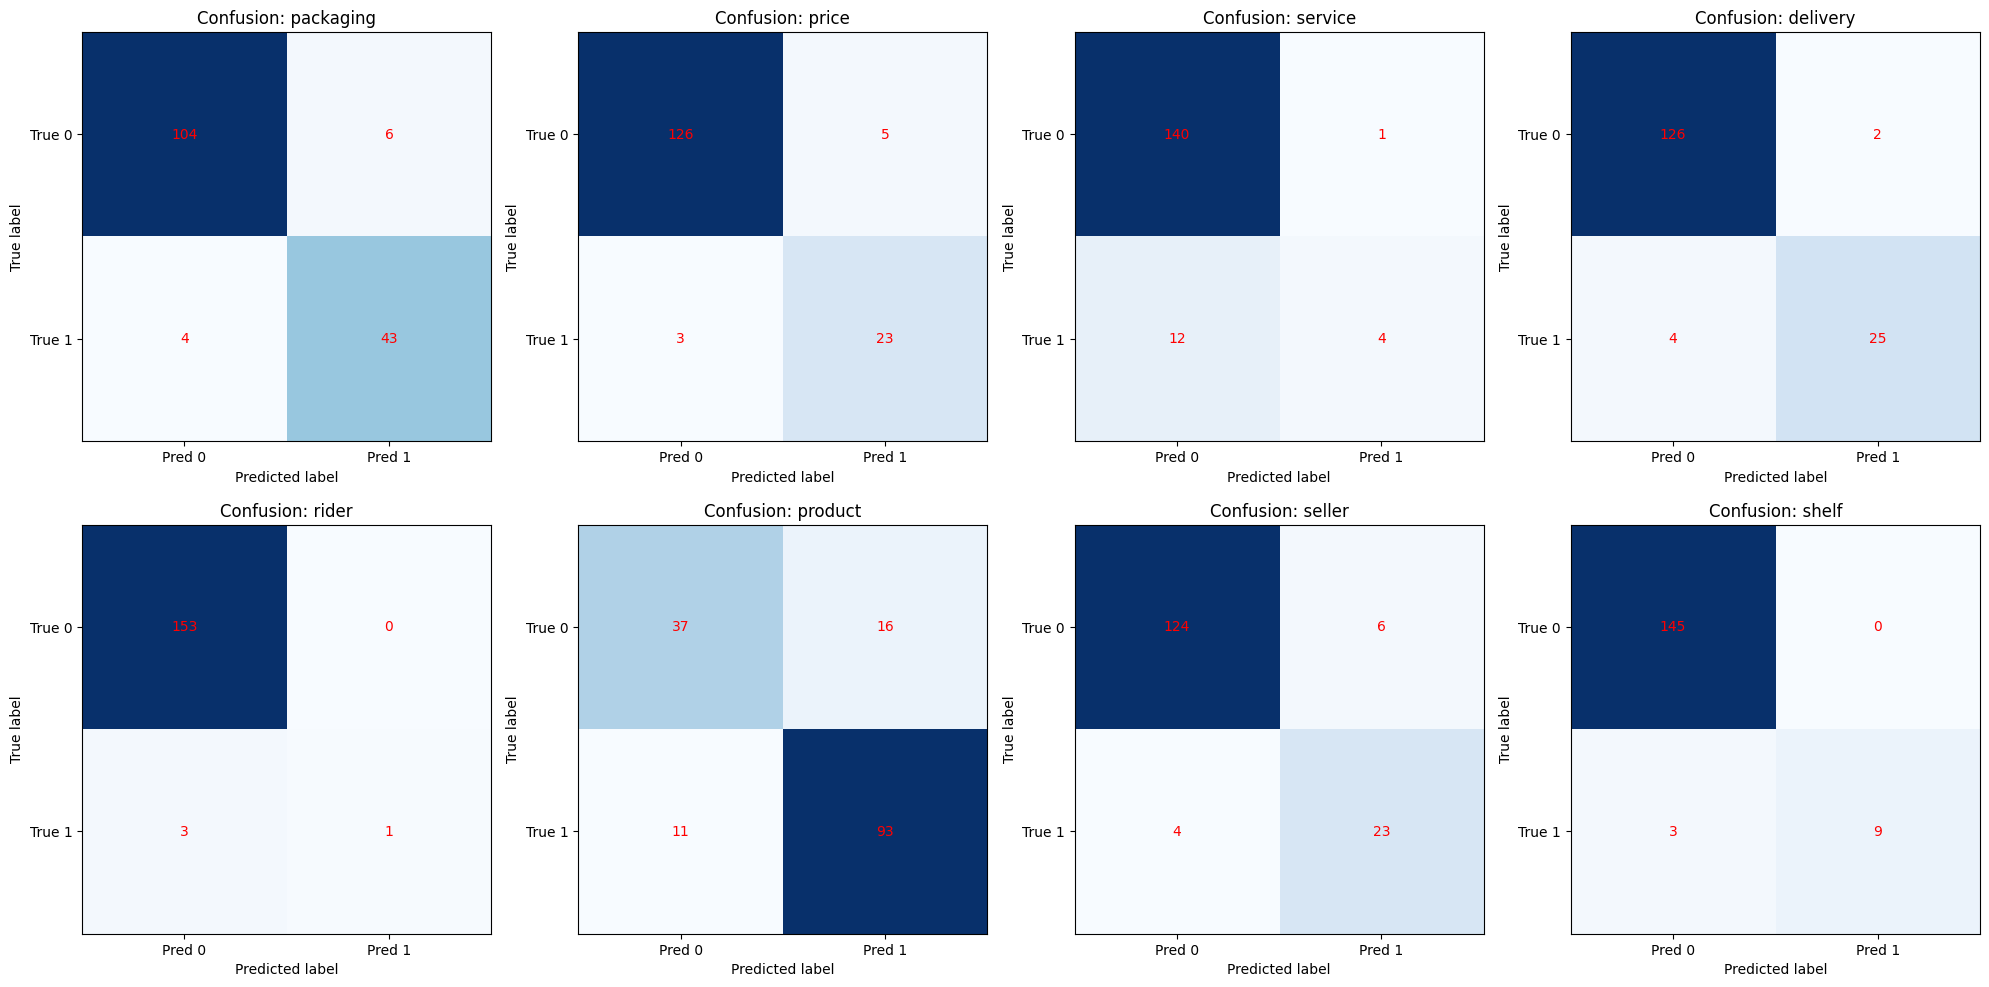

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, classification_report
# Compute multi-label confusion matrices
mcm = multilabel_confusion_matrix(target_values, predictions)

# Plot all 8 confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i in range(8):
    cm = mcm[i]
    ax = axes[i]
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Confusion: {target_list[i]}')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])

    for j in range(2):
        for k in range(2):
            ax.text(k, j, cm[j, k], ha='center', va='center', color='red')

    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()


# > **Inference**

In [99]:
# raw text
raw_text = """
১০০% আসল প্রোডাক্ট। সিলেটের মধ্যে ৮ দিনের মধ্যে ডেলিভারি হয়েছে। বিক্রেতা খুবই সহানুভূতিশীল এবং ভালো ছিলেন। এই প্রোডাক্টটি এই বিক্রেতার কাছ থেকে কেনার জন্য অত্যন্ত সুপারিশ করছি।
"""

In [100]:
encoded_text = tokenizer.encode_plus(
    raw_text,
    max_length=MAX_LEN,
    add_special_tokens=True,
    return_token_type_ids=True,
    pad_to_max_length=True,
    return_attention_mask=True,
    return_tensors='pt',
)

input_ids = encoded_text['input_ids'].to(device)
attention_mask = encoded_text['attention_mask'].to(device)
token_type_ids = encoded_text['token_type_ids'].to(device)
output = model(input_ids, attention_mask, token_type_ids)
 # add sigmoid, for the training sigmoid is in BCEWithLogitsLoss
output = torch.sigmoid(output).detach().cpu()
# thresholding at 0.5
output = output.flatten().round().numpy()
output

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2700: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


array([0., 0., 0., 1., 0., 1., 1., 0.], dtype=float32)

In [101]:
# Correctly identified the topic of the paper: High energy physics
print(f"Title: {raw_text}")
for idx, p in enumerate(output):
    if p==1:
        print(f"Label: {target_list[idx]}")

Title: 
১০০% আসল প্রোডাক্ট। সিলেটের মধ্যে ৮ দিনের মধ্যে ডেলিভারি হয়েছে। বিক্রেতা খুবই সহানুভূতিশীল এবং ভালো ছিলেন। এই প্রোডাক্টটি এই বিক্রেতার কাছ থেকে কেনার জন্য অত্যন্ত সুপারিশ করছি।

Label: delivery
Label: product
Label: seller


In [102]:
df.reviewContent[4]

' আসল প্রোডাক্ট সিলেটের মধ্যে  দিনের মধ্যে ডেলিভারি হয়েছে বিক্রেতা খুবই সহানুভূতিশীল এবং ভালো ছিলেন এই প্রোডাক্টটি এই বিক্রেতার কাছ থেকে কেনার জন্য অত্যন্ত সুপারিশ করছি'

In [103]:
df

,reviewContent,packaging,price,service,delivery,rider,product,seller,shelf
0,আলহামদুলিল্লাহ প্রোডাক্টটি অনেক ভালো সাউন্ড চে...,1,0,0,0,0,1,0,0
1,অসাধারণ একটা প্রডাক্ট হাতে পেলামসত্যিই অসাধারণ...,1,0,0,0,0,1,1,0
2,আসা করি যে ভালো হবে কিন্তু অনেক ভালো ছিল চালে ...,0,0,0,0,0,1,1,0
3,যেমন ওর্ডার করেছি তেমন পেয়েছিপ্যাকেটিং ভালো ছি...,1,0,0,0,0,1,1,0
4,আসল প্রোডাক্ট সিলেটের মধ্যে দিনের মধ্যে ডেলি...,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...
1643,পর্যাপ্ত মেয়াদ এবং প্যাকেজিং ভাল ছিলধন্যবাদ,1,0,0,0,0,0,0,1
1644,এই ম দারাজের থেকে ঠিকঠাক পন্য পেলাম \n সাথে ভে...,0,0,0,0,0,1,0,0
1645,প্যাকেজিং এবং পণ্য উভয়ই অসাধারণ,1,0,0,0,0,1,0,0
1646,আরে ভাই এটা বেবি আইটেম বাচ্চাদের দুধ এতো ব্যাক...,0,1,1,0,0,1,0,1
